In [305]:
import sys
sys.path.append('..')
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate  # TwoLocal, ZZFeatureMap, etc
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt

 ## Try Unitary AQC 

### Try MPF for the trotter evolution (?)

### Try differently

In [500]:
service = QiskitRuntimeService(instance='client-enablement/solutions/demo-testing')
backend = service.backend("ibm_torino")

qubit_subset = [4, 5, 6, 7, 8, 16, 17, 23, 24, 25, 26, 27] # trying 1 loop for torino
remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
rev_map = {val:key for key,val in remap.items()}

cm= backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a,b) if a<b else (b,a) for a,b in list(reduced_map.get_edges())}
ent_dec = [(rev_map[i], rev_map[j]) for i,j in edge_list]

def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()
H = Heisenberg(1, 12, edge_list)


def prep_psi_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9)
    qc.cx(9,10)
    qc.cx(10,11)
    qc.cx(9,8)
    qc.cx(11,6)
    qc.cx(8,7)
    qc.cx(7,5)
    qc.cx(6,4)
    qc.cx(4,3)
    qc.cx(5,0)
    qc.cx(3,2)
    #make checkpoints
    qc.cx(11, 17)
    qc.cx(4, 16)
    qc.cx(2, 15)
    qc.cx(0, 14)
    qc.cx(7, 13)
    #undo entanglement on undesired qubits
    qc.cx(2,3)
    qc.cx(4,6)
    qc.cx(11,10)
    qc.cx(9,8)
    qc.cx(7,5)
    return qc

def prep_psi_0_by_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9, ctrl_state='0')
    qc.cx(17, 11, ctrl_state='0')
    qc.cx(16,4, ctrl_state='0')
    qc.cx(15,2, ctrl_state='0')
    qc.cx(14,0, ctrl_state='0')
    qc.cx(13,7, ctrl_state='0')
    return qc



In [501]:
from qiskit.transpiler import generate_preset_pass_manager 

t_steps = 4
circuits = np.ndarray([t_steps,t_steps], dtype= QuantumCircuit)
H_tilde = np.zeros([t_steps,t_steps], dtype=complex)
S_tilde = np.zeros([t_steps,t_steps], dtype=complex)
delta_t = np.pi/40

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2*delta_t,0,1)
Rxyz_circ.ryy(2*delta_t,0,1)
Rxyz_circ.rzz(2*delta_t,0,1)
Rxyz_instr = Rxyz_circ.to_instruction(label='RXX+YY+ZZ')
qc_temp = QuantumCircuit(12)
for edge in edge_list:
    qc_temp.append(Rxyz_instr,edge)
time_evol = QuantumCircuit(12).compose(qc_temp)

real_obs_H = SparsePauliOp('XXXXXX', 1) ^ H 
imag_obs_H = SparsePauliOp('YXXXXX', 1) ^ H
real_obs_S = SparsePauliOp('XXXXXX', 1) ^ SparsePauliOp('I'*12, 1)
imag_obs_S = SparsePauliOp('YXXXXX', 1) ^ SparsePauliOp('I'*12, 1)



for j in range(t_steps):
    for i in range(j+1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]



In [502]:
f'Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}'

'Max circuit depth:31'

In [503]:
f'Max number of 2q gates= {max([circs[i][j].num_nonlocal_gates() for i in range(t_steps) for j in range(t_steps)])}'

'Max number of 2q gates= 135'

### Circuit execution

In [504]:
#basis state has energy -12
from qiskit_ibm_runtime import EstimatorV2, Batch, EstimatorOptions
pub1=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[0:2] for circ in circ_list]
pub2=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[2:4] for circ in circ_list]


with Batch(backend=backend) as batch:
    estimator = EstimatorV2(mode=batch)
    estimator.options.default_shots = 50000
    estimator.options.resilience_level = 2
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = 'XY4'
    est_job_1 = estimator.run(pub1)
    est_job_2 = estimator.run(pub2)


   

In [505]:
est_job_1_results = service.job(est_job_1.job_id()).result()

est_job_2_results = service.job(est_job_2.job_id()).result()

In [506]:
idx=0
for i in range(2):
    for j in range(t_steps):
            H_tilde[i,j] = est_job_1_results[idx].data.evs[0] + 1j * est_job_1_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_1_results[idx].data.evs[2] + 1j * est_job_1_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(2,4):
    for j in range(t_steps):
            H_tilde[i,j] = est_job_2_results[idx].data.evs[0] + 1j * est_job_2_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_2_results[idx].data.evs[2] + 1j * est_job_2_results[idx].data.evs[3]
            idx+=1

In [507]:
S_tilde

array([[ 0.69946796-3.85628934e-02j, -0.00581894+7.78183122e-01j,
        -0.11263552-1.12232137e-01j,  0.02695257-2.47747352e-16j],
       [-0.00123613+6.86103089e-01j,  0.90273957+4.51543122e-02j,
        -0.01792642+6.55509026e-01j, -0.11872362-2.02493087e-01j],
       [-0.48081219-2.75812439e-02j, -0.01636454+5.50376668e-01j,
         0.64358354+2.43864445e-02j, -0.03441547+3.84930149e-01j],
       [ 0.07010509-9.20089020e-03j, -0.2060399 -1.40853910e-02j,
        -0.00823181+5.19823932e-01j,  0.59533237-5.28371259e-18j]])

In [508]:
H_tilde

array([[ -8.44333596+0.14245329j,   2.74579339-8.37891521j,
          3.01034548+2.84326959j,  -1.09273427+0.06733593j],
       [  3.00481868-6.79045892j, -10.34833166-0.02286017j,
          3.06635479-7.18659594j,   1.73175379+2.03305077j],
       [  2.60917303+2.91521246j,   1.9482249 -6.46792395j,
         -8.13372762-0.01176174j,   1.35445572-5.25103292j],
       [ -1.14522486+0.01700737j,   1.23221927+2.3067852j ,
          1.61803542-4.31237655j,  -6.98715115-0.02989613j]])

1
2
3
GSE`s: [np.complex128(-12.045698350647793-0.4604409565190897j), np.complex128(-13.034510992597992-2.455600853547015j), np.complex128(-13.1416135957692-1.3365745940665335j)]


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

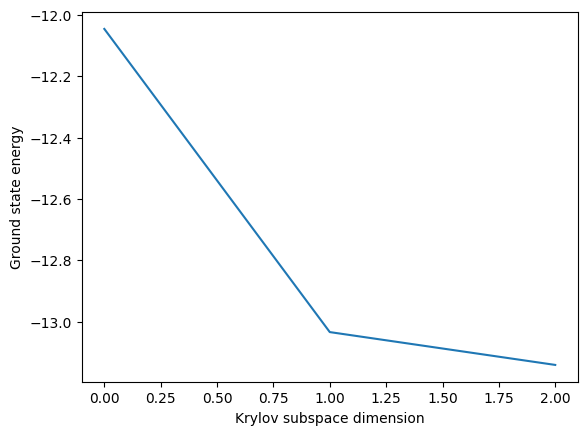

In [509]:
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-8)
print(f'GSE`s: {GSEs}')
plt.plot(GSEs) # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel('Krylov subspace dimension')
plt.ylabel('Ground state energy')

# Run on simulator for comparison

In [488]:
from qiskit.transpiler import generate_preset_pass_manager 

t_steps = 4
circuits = np.ndarray([t_steps,t_steps], dtype= QuantumCircuit)
H_tilde = np.zeros([t_steps,t_steps], dtype=complex)
S_tilde = np.zeros([t_steps,t_steps], dtype=complex)
delta_t = np.pi/40

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2*delta_t,0,1)
Rxyz_circ.ryy(2*delta_t,0,1)
Rxyz_circ.rzz(2*delta_t,0,1)
Rxyz_instr = Rxyz_circ.to_instruction(label='RXX+YY+ZZ')
qc_temp = QuantumCircuit(12)
for edge in edge_list:
    qc_temp.append(Rxyz_instr,edge)
time_evol = QuantumCircuit(12).compose(qc_temp)

real_obs_H = SparsePauliOp('XXXXXX', 1) ^ H 
imag_obs_H = SparsePauliOp('YXXXXX', 1) ^ H
real_obs_S = SparsePauliOp('XXXXXX', 1) ^ SparsePauliOp('I'*12, 1)
imag_obs_S = SparsePauliOp('YXXXXX', 1) ^ SparsePauliOp('I'*12, 1)



for j in range(t_steps):
    for i in range(j+1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])



sv_job=sv.run([(circs[i][j], [real_obs_H, imag_obs_H,real_obs_S, imag_obs_S]) for i in range(t_steps) for j in range(t_steps)])

sv_res = sv_job.result()

In [489]:
idx=0
for i in range(t_steps):
    for j in range(t_steps):
            H_tilde[i,j] = sv_res[idx].data.evs[0] + 1j * sv_res[idx].data.evs[1]
            S_tilde[i,j] = sv_res[idx].data.evs[2] + 1j * sv_res[idx].data.evs[3]
            idx+=1
print(H_tilde)

print(S_tilde)

[[-12.        +0.00000000e+00j   6.44605962-9.32576050e+00j
    3.23814767+8.53998277e+00j  -5.5527575 -2.01013286e+00j]
 [  6.44605962-9.32576050e+00j -11.96300088-2.15108107e-16j
    6.43232415-9.26373005e+00j   3.18151687+8.50887092e+00j]
 [  3.23814767+8.53998277e+00j   6.43232415-9.26373005e+00j
  -11.86784426+5.10306489e-16j   6.40985317-9.16623135e+00j]
 [ -5.5527575 -2.01013286e+00j   3.18151687+8.50887092e+00j
    6.40985317-9.16623135e+00j -11.75405599+1.45236677e-17j]]
[[ 1.        +0.j         -0.26633086+0.8196821j  -0.40786385-0.36717711j
   0.2595403 -0.03745379j]
 [-0.26633086+0.8196821j   1.        +0.j         -0.26633086+0.8196821j
  -0.40786385-0.36717711j]
 [-0.40786385-0.36717711j -0.26633086+0.8196821j   1.        +0.j
  -0.26633086+0.8196821j ]
 [ 0.2595403 -0.03745379j -0.40786385-0.36717711j -0.26633086+0.8196821j
   1.        +0.j        ]]


1
2
3


Text(0, 0.5, 'Ground state energy')

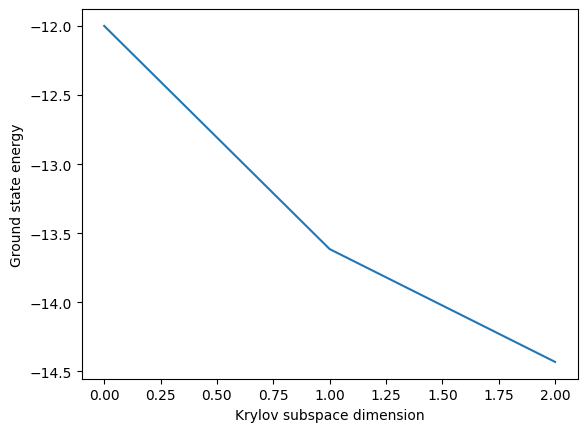

In [490]:
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-8)
plt.plot(GSEs) # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel('Krylov subspace dimension')
plt.ylabel('Ground state energy')